<a href="https://colab.research.google.com/github/AndreiMatosha/ML-Basic/blob/main/Breast_Cancer_EDA_kNN.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Breast Cancer Wisconsin (Diagnostic)
## EDA and kNN Modeling

Этот notebook содержит:
- Исследовательский анализ данных (EDA)
- Визуализации
- Модель kNN
- Подбор гиперпараметров

Файл данных должен называться **data.csv** и находиться в той же папке.

In [1]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("uciml/breast-cancer-wisconsin-data")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'breast-cancer-wisconsin-data' dataset.
Path to dataset files: /kaggle/input/breast-cancer-wisconsin-data


In [2]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_curve, roc_auc_score
)

sns.set(style='whitegrid')
plt.rcParams['figure.figsize'] = (8,5)

## Load data

In [3]:
df = pd.read_csv('/kaggle/input/breast-cancer-wisconsin-data/data.csv')

# Remove unnamed columns if present
df = df.loc[:, ~df.columns.str.contains('^Unnamed')]

df.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678


## Preprocessing

In [4]:
df['diagnosis'] = df['diagnosis'].map({'M': 1, 'B': 0})

df['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


## Basic statistics

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,569.0,3.037183e+07,1.250206e+08,8670.000000,869218.000000,906024.000000,8.813129e+06,9.113205e+08
diagnosis,569.0,3.725835e-01,4.839180e-01,0.000000,0.000000,0.000000,1.000000e+00,1.000000e+00
radius_mean,569.0,1.412729e+01,3.524049e+00,6.981000,11.700000,13.370000,1.578000e+01,2.811000e+01
texture_mean,569.0,1.928965e+01,4.301036e+00,9.710000,16.170000,18.840000,2.180000e+01,3.928000e+01
perimeter_mean,569.0,9.196903e+01,2.429898e+01,43.790000,75.170000,86.240000,1.041000e+02,1.885000e+02
area_mean,569.0,6.548891e+02,3.519141e+02,143.500000,420.300000,551.100000,7.827000e+02,2.501000e+03
smoothness_mean,569.0,9.636028e-02,1.406413e-02,0.052630,0.086370,0.095870,1.053000e-01,1.634000e-01
compactness_mean,569.0,1.043410e-01,5.281276e-02,0.019380,0.064920,0.092630,1.304000e-01,3.454000e-01
concavity_mean,569.0,8.879932e-02,7.971981e-02,0.000000,0.029560,0.061540,1.307000e-01,4.268000e-01
concave points_mean,569.0,4.891915e-02,3.880284e-02,0.000000,0.020310,0.033500,7.400000e-02,2.012000e-01


## Feature distributions by target

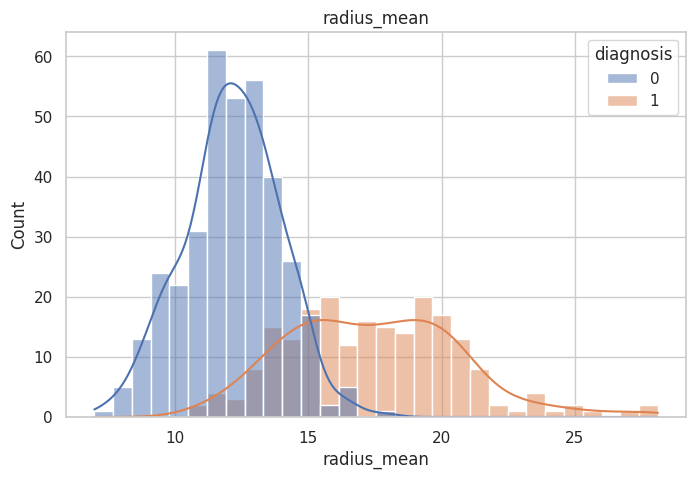

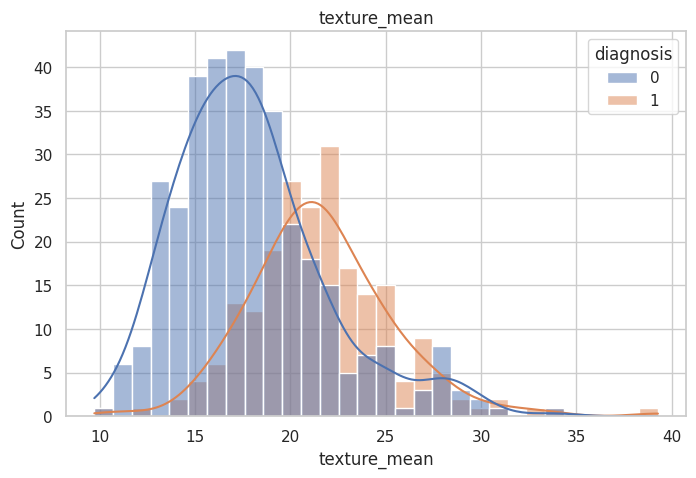

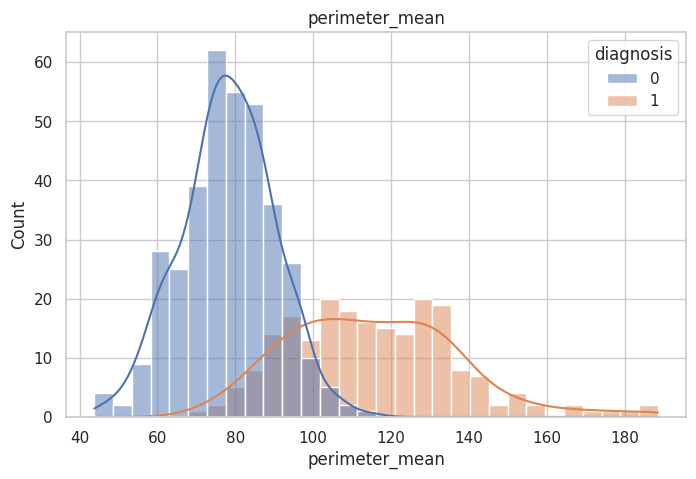

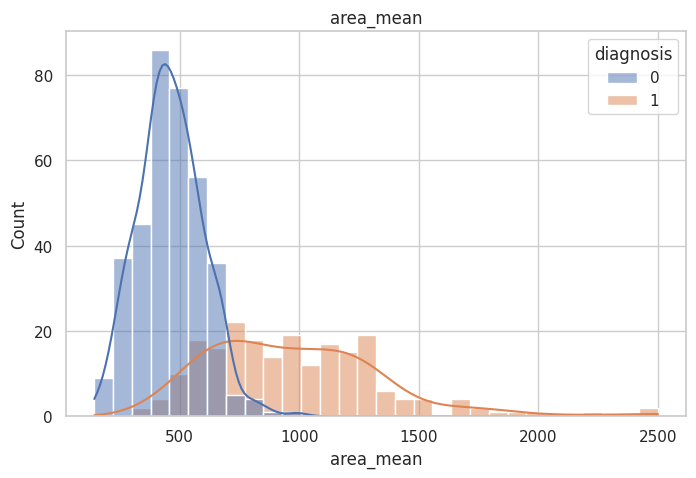

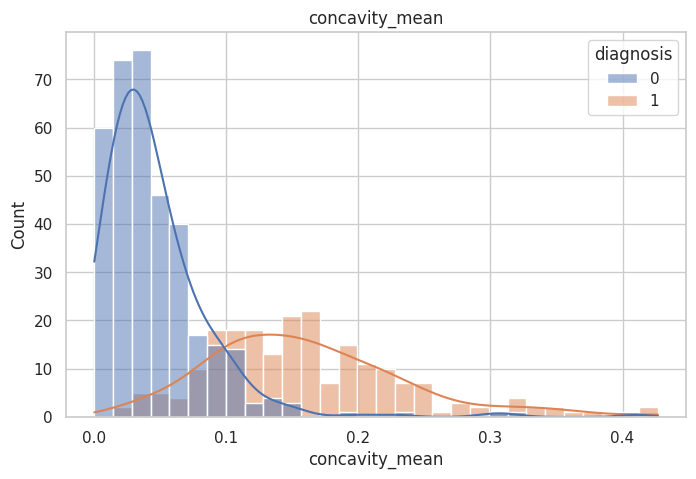

In [6]:
features_to_plot = [
    'radius_mean',
    'texture_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean'
]

for feature in features_to_plot:
    plt.figure()
    sns.histplot(data=df, x=feature, hue='diagnosis', bins=30, kde=True)
    plt.title(feature)
    plt.show()

## Correlation heatmap

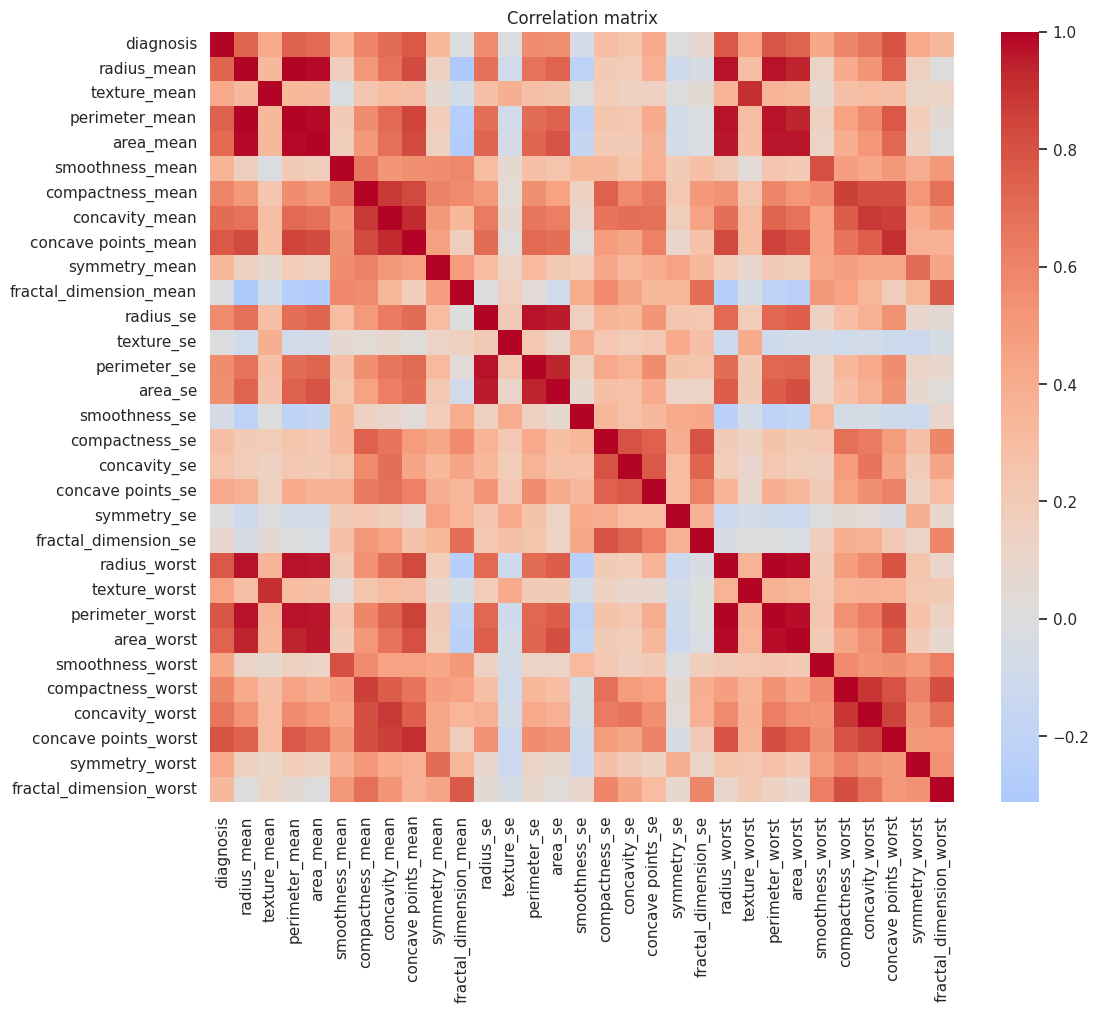

In [7]:
corr = df.drop(columns=['id']).corr()

plt.figure(figsize=(12,10))
sns.heatmap(corr, cmap='coolwarm', center=0)
plt.title('Correlation matrix')
plt.show()

## Scatterplots for highly correlated features

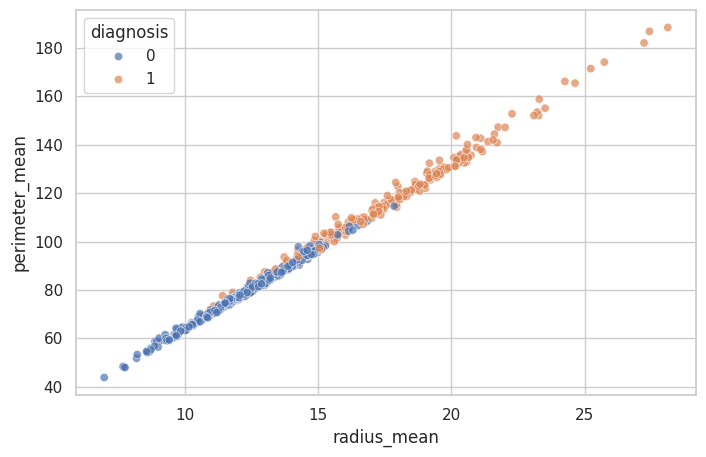

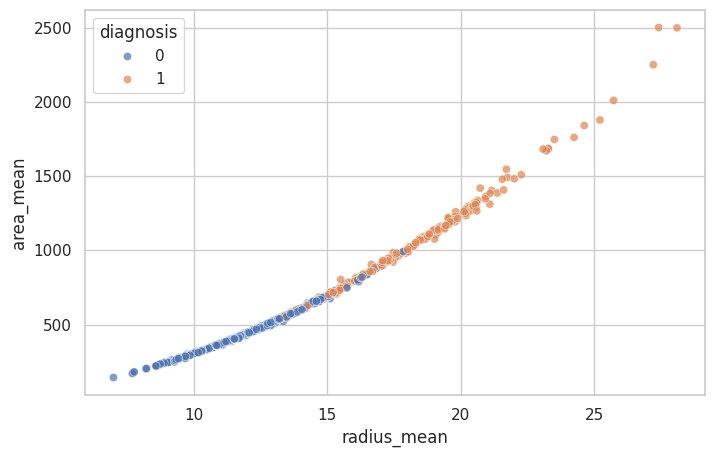

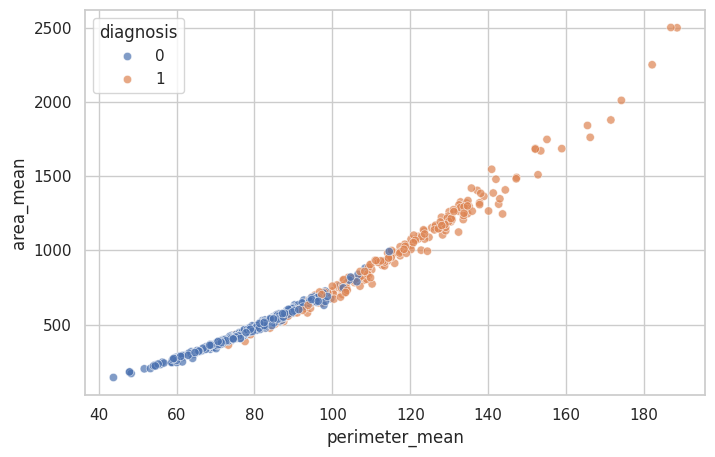

In [8]:
pairs = [
    ('radius_mean', 'perimeter_mean'),
    ('radius_mean', 'area_mean'),
    ('perimeter_mean', 'area_mean')
]

for x, y in pairs:
    plt.figure()
    sns.scatterplot(data=df, x=x, y=y, hue='diagnosis', alpha=0.7)
    plt.show()

## Boxplots by diagnosis

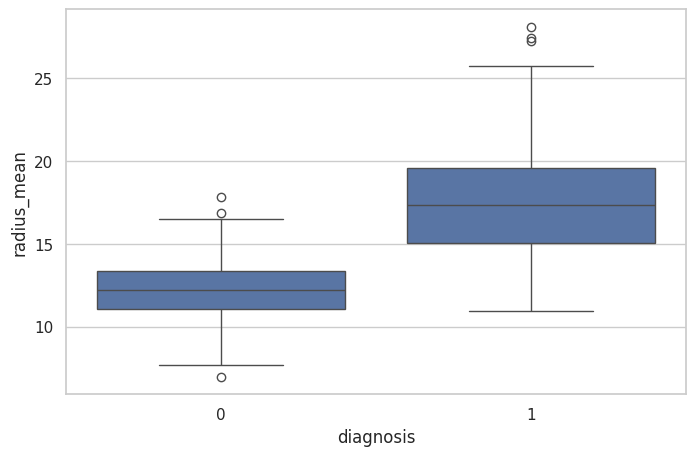

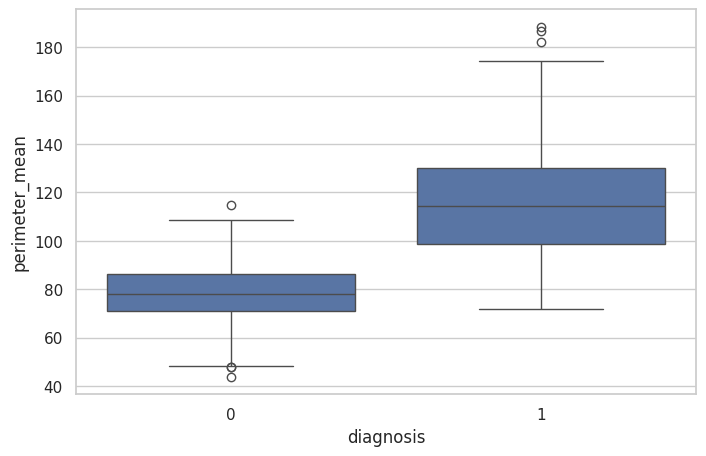

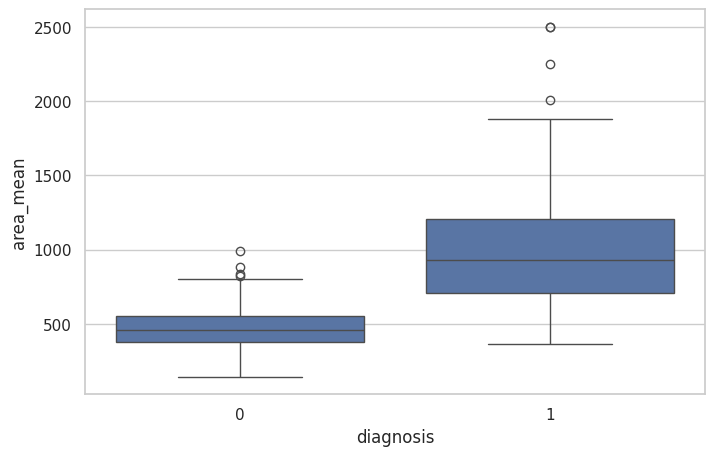

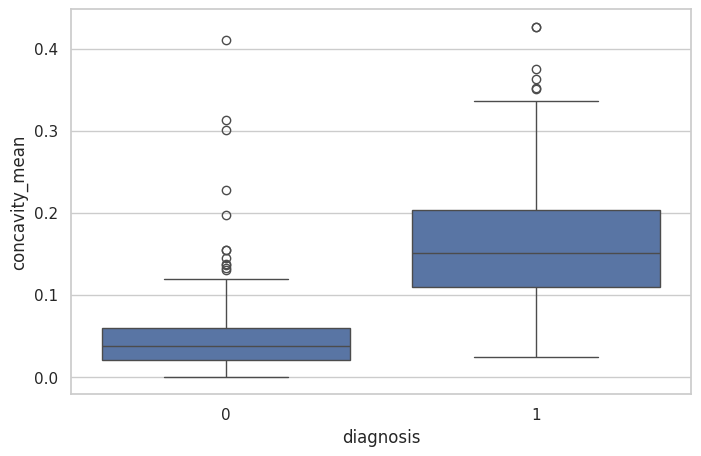

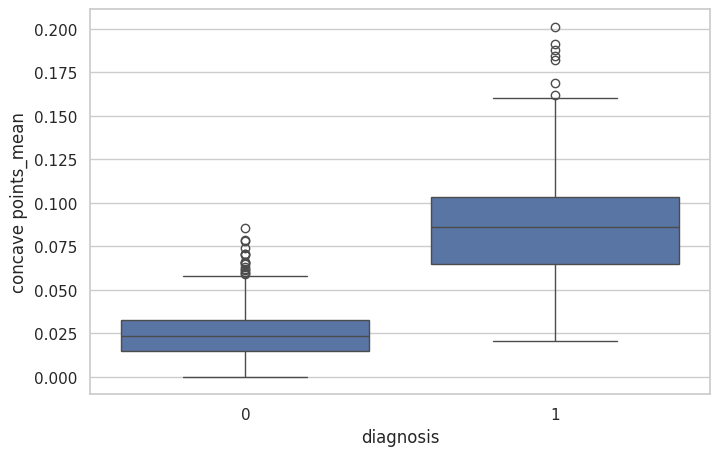

In [9]:
important_features = [
    'radius_mean',
    'perimeter_mean',
    'area_mean',
    'concavity_mean',
    'concave points_mean'
]

for feature in important_features:
    plt.figure()
    sns.boxplot(data=df, x='diagnosis', y=feature)
    plt.show()

# kNN Modeling

In [10]:
X = df.drop(columns=['diagnosis', 'id'])
y = df['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=42,
    stratify=y
)

## Standardization
kNN использует расстояния между объектами. Если признаки имеют разные масштабы, признаки с большими значениями будут доминировать.

In [11]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

## Default kNN

In [12]:
knn = KNeighborsClassifier()
knn.fit(X_train_scaled, y_train)

y_pred = knn.predict(X_test_scaled)
y_proba = knn.predict_proba(X_test_scaled)[:,1]

print('Accuracy:', accuracy_score(y_test, y_pred))
print('Precision:', precision_score(y_test, y_pred))
print('Recall:', recall_score(y_test, y_pred))
print('F1:', f1_score(y_test, y_pred))
print('ROC AUC:', roc_auc_score(y_test, y_proba))

Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.90625
F1: 0.9508196721311475
ROC AUC: 0.9881717289719626


## ROC curve

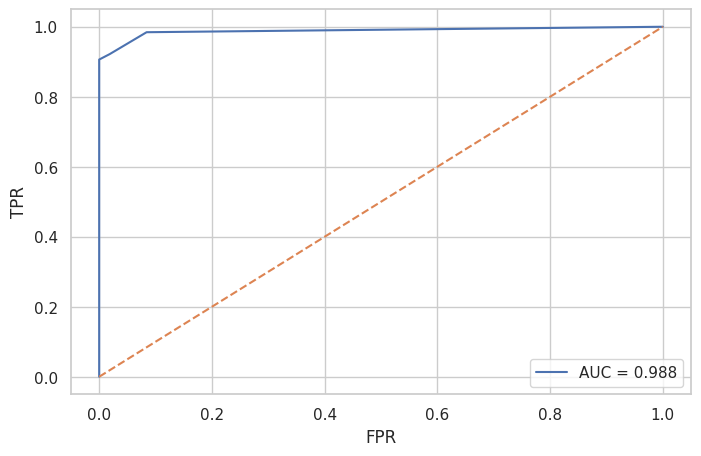

In [13]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
auc = roc_auc_score(y_test, y_proba)

plt.figure()
plt.plot(fpr, tpr, label=f'AUC = {auc:.3f}')
plt.plot([0,1], [0,1], linestyle='--')
plt.xlabel('FPR')
plt.ylabel('TPR')
plt.legend()
plt.show()

## Hyperparameter tuning

In [14]:
param_grid = {'n_neighbors': list(range(1,31))}

grid = GridSearchCV(
    KNeighborsClassifier(),
    param_grid,
    cv=5,
    scoring='f1'
)

grid.fit(X_train_scaled, y_train)

grid.best_params_

{'n_neighbors': 5}

In [15]:
best_knn = grid.best_estimator_

y_pred_best = best_knn.predict(X_test_scaled)
y_proba_best = best_knn.predict_proba(X_test_scaled)[:,1]

print('Best k:', grid.best_params_['n_neighbors'])
print('Accuracy:', accuracy_score(y_test, y_pred_best))
print('Precision:', precision_score(y_test, y_pred_best))
print('Recall:', recall_score(y_test, y_pred_best))
print('F1:', f1_score(y_test, y_pred_best))
print('ROC AUC:', roc_auc_score(y_test, y_proba_best))

Best k: 5
Accuracy: 0.9649122807017544
Precision: 1.0
Recall: 0.90625
F1: 0.9508196721311475
ROC AUC: 0.9881717289719626
